# Group H: Math2130 Final Project Models
* Seungwoo Johnson, Aayushi Garg, Sarah Kamoun, Prabhleen Luthra, Karen Lau

# Importing the Libraries

In [9]:
### Load relevant packages

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.api         as sm
import statsmodels.formula.api as smf
import os
import folium

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
from sklearn.metrics import accuracy_score, classification_report

from itertools import combinations
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from scipy.stats import linregress

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.feature_selection import SelectFromModel

%matplotlib inline

plt.style.use('ggplot')

In [10]:
# read cleaned dataframe
df2 = pd.read_csv('cleaned_data.csv')
#check nb rows
print(len(df2))

4515470


In [11]:
df2['time'] = pd.to_datetime(df2['time'])

In [12]:
# drop the rows with 0 oxygen
df2 = df2[df2['micromoles_of_oxygen_per_unit_mass_in_sea_water'] != 0]

## New Data Overview

In [13]:
df2.describe()# numerical vars (here it includes binary vars as well)

,time,latitude,longitude,depth,sea_water_temperature,sea_water_practical_salinity,sea_water_density,micromoles_of_oxygen_per_unit_mass_in_sea_water,lat_binF,lon_binF,hour
count,4515455,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06,4.515455e+06
mean,2020-12-27 19:59:01.801829888,4.767400e+01,-6.377606e+01,3.131330e+01,5.846132e+00,3.001339e+01,1.023588e+03,2.623632e+02,4.767360e+01,-6.377623e+01,1.141958e+01
min,2018-07-20 01:02:01,4.717068e+01,-6.443135e+01,0.000000e+00,-1.030950e+00,2.550691e+01,1.017595e+03,1.675206e+02,4.715000e+01,-6.445000e+01,0.000000e+00
25%,2019-07-11 05:50:19,4.750765e+01,-6.400372e+01,1.342134e+01,9.228000e-01,2.888840e+01,1.022143e+03,2.402955e+02,4.750000e+01,-6.400000e+01,5.000000e+00
50%,2020-08-05 20:05:31,4.763927e+01,-6.382851e+01,2.923201e+01,3.033500e+00,3.051187e+01,1.024454e+03,2.626329e+02,4.765000e+01,-6.385000e+01,1.100000e+01
75%,2022-08-03 01:45:24,4.780545e+01,-6.353496e+01,4.688049e+01,9.694167e+00,3.114273e+01,1.025176e+03,2.845298e+02,4.780000e+01,-6.355000e+01,1.700000e+01
max,2023-08-08 21:21:56,4.842718e+01,-6.307820e+01,9.712120e+01,2.254805e+01,3.316643e+01,1.026917e+03,4.699518e+02,4.845000e+01,-6.310000e+01,2.300000e+01
std,NaN,2.175631e-01,2.773039e-01,2.000841e+01,6.187917e+00,1.541903e+00,2.119726e+00,2.882127e+01,2.178725e-01,2.777256e-01,6.930817e+00


New Variables to create:

*   Year_n (Year number)
* Month_n (Month number, ranging between 1 and 12)
* Week_n (Week number, ranging between 1 and 52 )
* Day_n (Day number, ranging between 1 and 365)
* Season (Spring, Summer, Fall, Winter - not all months are available in the dataset)
* DayNight (Binary “1”: if hour is between 6:00 to 18:00 ; “0”: otherwise)
* Depth_level:("Upper" if 0 to 32, "Mid" if 33 to 65, "Lower" if 66 to 99)



In [14]:
df2['time'] = pd.to_datetime(df2['time'])
df2['Year_n'] = df2['time'].dt.year.astype('category')# the year
df2['Month_n'] = df2['time'].dt.month.astype('category')# month of a year
df2['Hour_n'] = df2['time'].dt.hour.astype('category')# hour of a day
df2['Week_n'] = df2['time'].dt.isocalendar().week.astype('category')# week of the year
df2['Day_n'] = df2['time'].dt.dayofyear.astype('category')# day of the year
df2['Depth_level'] = pd.cut(df2['depth'], bins=[0, 32, 65, 99], labels=['Upper', 'Mid', 'Lower']).astype('category')
df2['Season'] = df2['time'].dt.month.apply(lambda x: 'Spring' if 3 <= x <= 5 else ('Summer' if 6 <= x <= 8 else ('Fall' if 9 <= x <= 11 else 'Winter'))).astype('category')
df2['DayNight'] = df2['time'].dt.hour.apply(lambda x: 1 if 6 <= x <= 18 else 0).astype(int)# day or night

In [15]:
print(df2.dtypes)

time                                               datetime64[ns]
latitude                                                  float64
longitude                                                 float64
depth                                                     float64
sea_water_temperature                                     float64
sea_water_practical_salinity                              float64
sea_water_density                                         float64
micromoles_of_oxygen_per_unit_mass_in_sea_water           float64
lat_binF                                                  float64
lon_binF                                                  float64
hour                                                        int64
Year_n                                                   category
Month_n                                                  category
Hour_n                                                   category
Week_n                                                   category
Day_n     

In [16]:
#plotting one data sample
df2.head(1)

,time,latitude,longitude,depth,sea_water_temperature,sea_water_practical_salinity,sea_water_density,micromoles_of_oxygen_per_unit_mass_in_sea_water,lat_binF,lon_binF,hour,Year_n,Month_n,Hour_n,Week_n,Day_n,Depth_level,Season,DayNight
0,2020-07-17 18:52:10,47.41705,-63.907473,23.203598,3.0303,30.195456,1024.161834,290.02155,47.4,-63.9,18,2020,7,18,29,199,Upper,Summer,1


In [17]:
  # Create interaction terms (combinations of variables)
  df2['temp_salinity'] = df2['sea_water_temperature'] * df2['sea_water_practical_salinity']
  df2['temp_density'] = df2['sea_water_temperature'] * df2['sea_water_density']
  df2['temp_depth'] = df2['sea_water_temperature'] * df2['depth']
  df2['salinity_density'] = df2['sea_water_practical_salinity'] * df2['sea_water_density']
  df2['salinity_depth'] = df2['sea_water_practical_salinity'] * df2['depth']
  df2['density_depth'] = df2['sea_water_density'] * df2['depth']

# Model

In [18]:
print(df2.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density',
       'micromoles_of_oxygen_per_unit_mass_in_sea_water', 'lat_binF',
       'lon_binF', 'hour', 'Year_n', 'Month_n', 'Hour_n', 'Week_n', 'Day_n',
       'Depth_level', 'Season', 'DayNight', 'temp_salinity', 'temp_density',
       'temp_depth', 'salinity_density', 'salinity_depth', 'density_depth'],
      dtype='object')


## Random Forest Regressor Model

Random Forest Results:
Training MSE: 0.0006, Training RMSE: 0.0246, Training R²: 0.9417
Test MSE: 0.0041, Test RMSE: 0.0640, Test R²: 0.6173


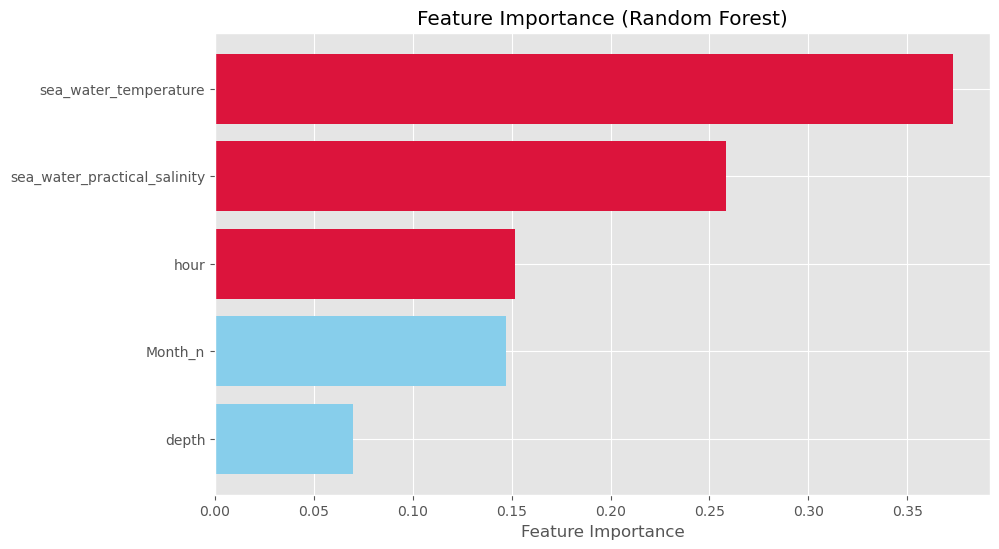

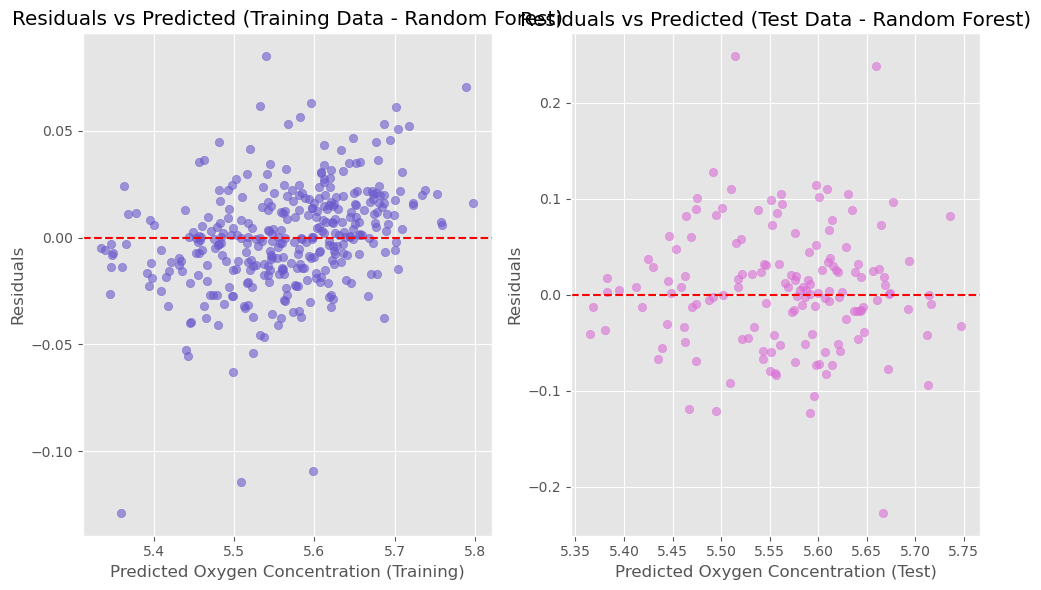

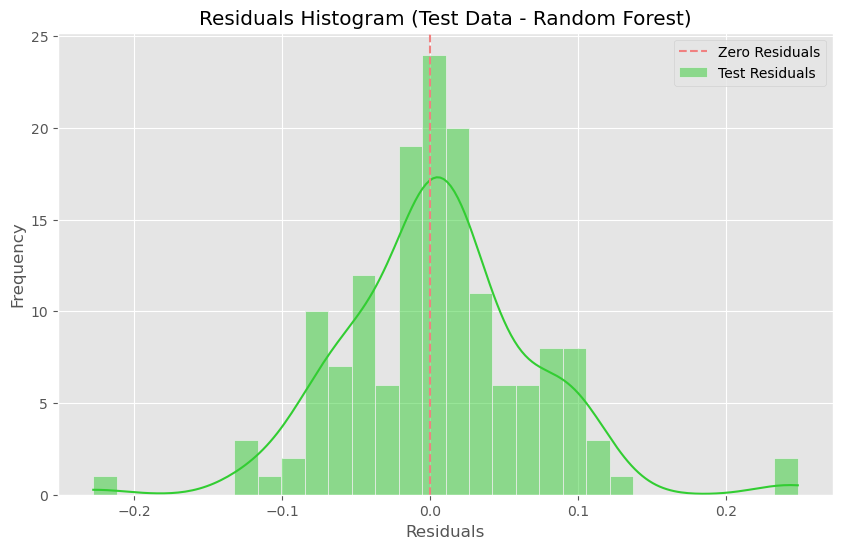

Best Parameters from GridSearchCV: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


C:\Users\zelko\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
251 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\zelko\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\zelko\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\zelko\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\zelko\anaconda3\Lib\site-packa

In [19]:

# Define the target and features for filtered data
# No Density since it is highly correlated to other variables
features = ['sea_water_temperature', 'sea_water_practical_salinity','Month_n','depth','hour']
target = 'micromoles_of_oxygen_per_unit_mass_in_sea_water'

# Drop NaN values
df2 = df2.dropna(subset=features + [target])

# Use 500 samples (faster)
df2_filtered_sampled = df2.sample(n=500, random_state=42)

# Define the features (X) and target (y)
X_filtered_sampled = df2_filtered_sampled[features]
y_filtered_sampled = df2_filtered_sampled[target]

# Apply log transformation on the target variable
y_filtered_sampled_log = np.log1p(y_filtered_sampled)  # Log(x + 1) to handle zero values

# Select only numerical features for the square root transformation
X_filtered_sampled_numerical = X_filtered_sampled.select_dtypes(include=[np.number])

# Apply square root transformation to the numerical features
X_filtered_sampled_sqrt = X_filtered_sampled_numerical.apply(np.sqrt)

# Handle categorical features separately, if any
X_filtered_sampled_categorical = X_filtered_sampled.select_dtypes(exclude=[np.number])

# Concatenate the transformed numerical features and the original categorical features
X_filtered_sampled_transformed = pd.concat([X_filtered_sampled_sqrt, X_filtered_sampled_categorical], axis=1)

# 70/30 splits
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered_sampled_transformed, y_filtered_sampled_log, test_size=0.3, random_state=42)

# Initialize RandomForestRegressor with n_estimators=20 and max_features='sqrt'
rf_regressor = RandomForestRegressor(n_estimators=20, max_features='sqrt', random_state=42)

# Train the model
rf_regressor.fit(X_train_filtered, y_train_filtered)

# Predict on both training and test sets
y_train_pred_rf = rf_regressor.predict(X_train_filtered)
y_test_pred_rf = rf_regressor.predict(X_test_filtered)

# MSE, RMSE, and R² for both training and test sets
mse_train_rf = mean_squared_error(y_train_filtered, y_train_pred_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
r2_train_rf = r2_score(y_train_filtered, y_train_pred_rf)

mse_test_rf = mean_squared_error(y_test_filtered, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(y_test_filtered, y_test_pred_rf)

print("Random Forest Results:")
print(f"Training MSE: {mse_train_rf:.4f}, Training RMSE: {rmse_train_rf:.4f}, Training R²: {r2_train_rf:.4f}")
print(f"Test MSE: {mse_test_rf:.4f}, Test RMSE: {rmse_test_rf:.4f}, Test R²: {r2_test_rf:.4f}")


# Extra
# Feature Importance
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]

# Highlight top3
top_n = 3
highlight_color = 'crimson'
default_color = 'skyblue'
colors = [highlight_color if i < top_n else default_color for i in range(len(features))]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.barh(range(len(features)), importances[indices], align="center", color=colors)
plt.yticks(range(len(features)), np.array(features)[indices])
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()


# Residual
residuals_train_rf = y_train_filtered - y_train_pred_rf
residuals_test_rf = y_test_filtered - y_test_pred_rf

##
plt.figure(figsize=(10, 6))

# Residuals for training data
plt.subplot(1, 2, 1)
plt.scatter(y_train_pred_rf, residuals_train_rf, color='slateblue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Oxygen Concentration (Training)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Training Data - Random Forest)")

# Plot residuals for test data
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred_rf, residuals_test_rf, color='orchid', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Oxygen Concentration (Test)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test Data - Random Forest)")


plt.tight_layout()
plt.show()

# Residuals Histogram
plt.figure(figsize=(10, 6))
sns.histplot(residuals_test_rf, kde=True, color='limegreen', label='Test Residuals', bins=30)
plt.axvline(0, color='lightcoral', linestyle='--', label='Zero Residuals')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Histogram (Test Data - Random Forest)")
plt.legend()
plt.show()


# Extra to check the best model
# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Min. samples to split a node
    'min_samples_leaf': [1, 2, 4],    # Min. samples at a leaf node
    'max_features': ['auto', 'sqrt', 'log2']  # Number of features to consider
}

# Grid Search
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_filtered, y_train_filtered)

##
print("Best Parameters from GridSearchCV:", grid_search.best_params_)


Random Forest Results:

Training MSE: 0.0007, Training RMSE: 0.0272, Training R²: 0.9348

Test MSE: 0.0038, Test RMSE: 0.0615, Test R²: 0.6856

Temperature and Salinity shows the same result in terms of feature importance whereas depth shows the least

Residuals: The Residual plot shows homoscedasticity. The training residuals were clustered around zero, indicating a well-fitted model. In contrast, the test residuals were more widely spread, suggesting some generalization error.

The residual histogram are normally distributed centered around zero


<Figure size 800x600 with 0 Axes>

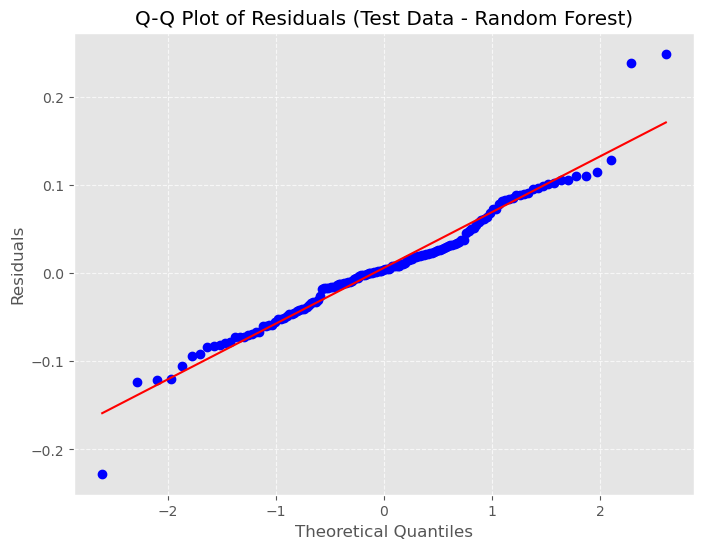

In [21]:

import scipy.stats as stats

# qqplots
plt.figure(figsize=(8, 6))
stats.probplot(residuals_test_rf, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (Test Data - Random Forest)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Residuals")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


The qq plot is linear showing normal distribution

## Polynomial Model

Training R²: 0.6174901776956875
Test R²: 0.6182635446465579
Training MSE: 317.7857545895521
Test MSE: 316.9027419321506


C:\Users\zelko\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


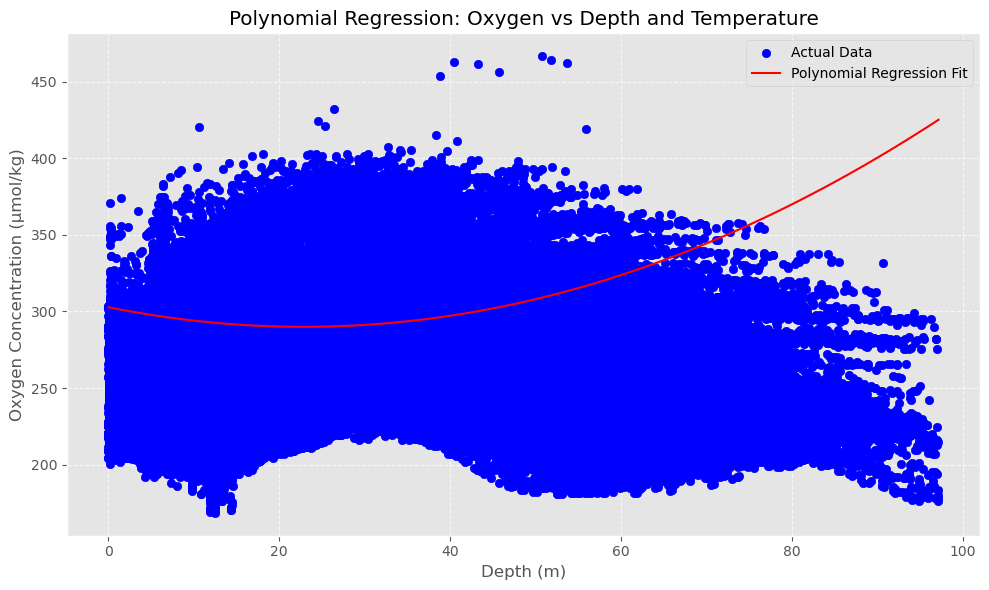

C:\Users\zelko\AppData\Local\Temp\ipykernel_49032\2512401415.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\zelko\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


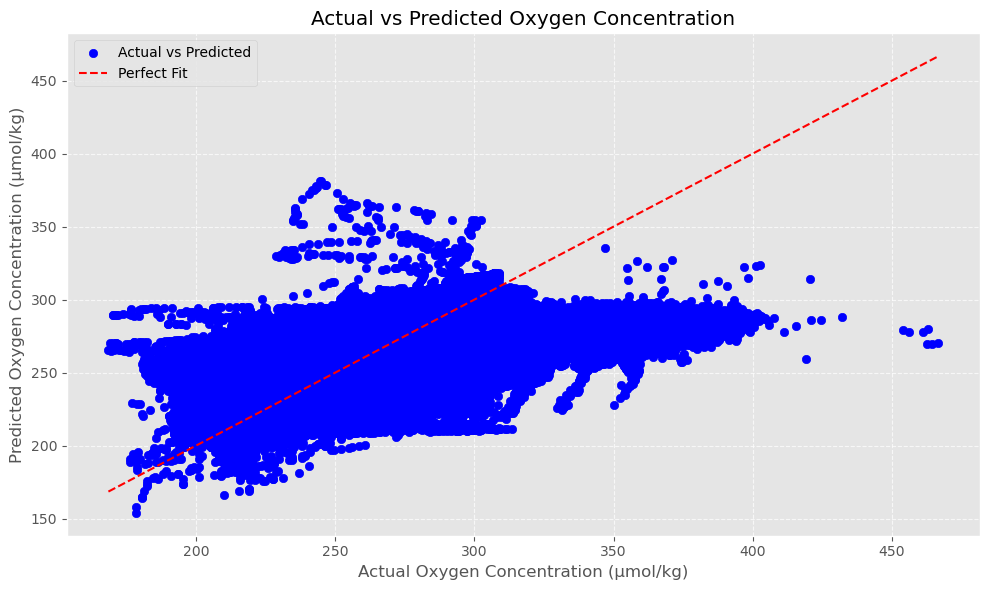

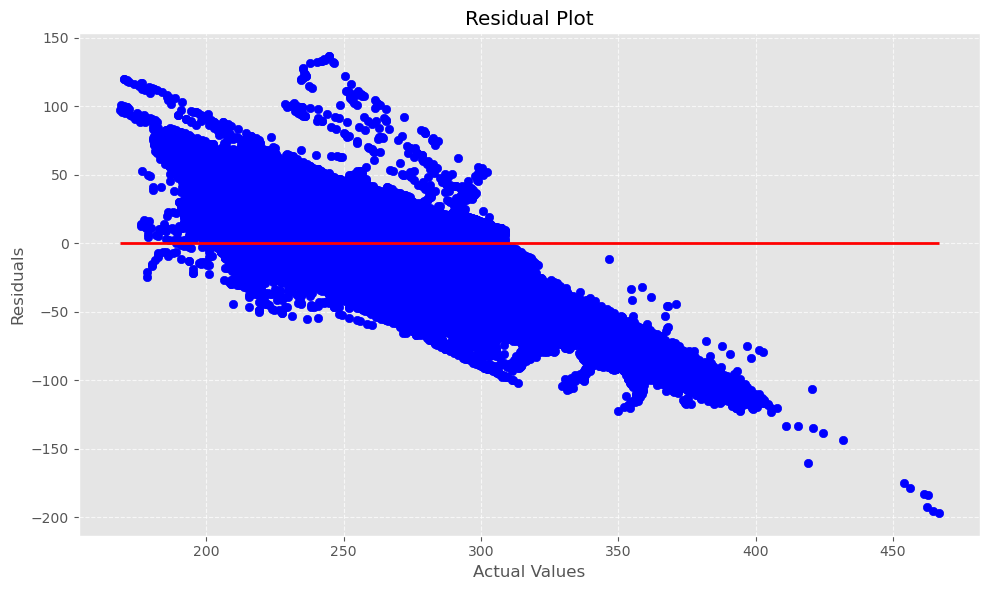

In [22]:
# Import necessary libraries
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Prepare the data
X = df2[['depth', 'sea_water_temperature', 'sea_water_practical_salinity', 'sea_water_density']]  # Features
y = df2['micromoles_of_oxygen_per_unit_mass_in_sea_water']  # Target variable (Oxygen concentration)

# Step 2: Create interaction features
df2['depth_temperature'] = df2['depth'] * df2['sea_water_temperature']
df2['salinity_density'] = df2['sea_water_practical_salinity'] * df2['sea_water_density']

# Add these new features to X
X = df2[['depth', 'sea_water_temperature', 'sea_water_practical_salinity', 'sea_water_density', 'depth_temperature', 'salinity_density']]

# Step 3: Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Scale the features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Transform features into polynomial features (degree 2 by default)
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train_scaled)
X_poly_test = poly.transform(X_test_scaled)

# Step 6: Train the model
model = LinearRegression()
model.fit(X_poly_train, y_train)

# Step 7: Make predictions
y_pred_train = model.predict(X_poly_train)
y_pred_test = model.predict(X_poly_test)

# Step 8: Evaluate the model performance
print(f"Training R²: {r2_score(y_train, y_pred_train)}")
print(f"Test R²: {r2_score(y_test, y_pred_test)}")
print(f"Training MSE: {mean_squared_error(y_train, y_pred_train)}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")

# Step 9: Visualizing Polynomial Regression for Depth and Temperature Combined vs Oxygen

# Create mean values of temperature, salinity, and density for the visualization
mean_temp = X_test['sea_water_temperature'].mean()  # mean of sea_water_temperature
mean_salinity = X_test['sea_water_practical_salinity'].mean()  # mean of sea_water_practical_salinity
mean_density = X_test['sea_water_density'].mean()  # mean of sea_water_density

# Create depth_temperature_range with depth, salinity, and density set to their mean values
depth_temp_range = np.array([[depth, mean_temp, mean_salinity, mean_density, depth * mean_temp, mean_salinity * mean_density]
                             for depth in np.linspace(X_test['depth'].min(), X_test['depth'].max(), 100)])

# Apply the same transformation used on the training set
depth_temp_range_scaled = scaler.transform(depth_temp_range)  # Apply scaling to input

# Transform the scaled depth range
depth_temp_poly = poly.transform(depth_temp_range_scaled)

# Predict oxygen concentration using the combined features
y_pred_depth_temp = model.predict(depth_temp_poly)

# Plotting the polynomial regression curve for Depth and Temperature
plt.figure(figsize=(10, 6))
plt.scatter(X_test['depth'], y_test, color='blue', label='Actual Data')
plt.plot(np.linspace(X_test['depth'].min(), X_test['depth'].max(), 100), y_pred_depth_temp, color='red', label='Polynomial Regression Fit')
plt.title('Polynomial Regression: Oxygen vs Depth and Temperature')
plt.xlabel('Depth (m)')
plt.ylabel('Oxygen Concentration (µmol/kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Step 10: Full Model - Actual vs Predicted Oxygen Concentration
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, color='blue', label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.title('Actual vs Predicted Oxygen Concentration')
plt.xlabel('Actual Oxygen Concentration (µmol/kg)')
plt.ylabel('Predicted Oxygen Concentration (µmol/kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Step 11: Residual Plot (Actual vs Predicted)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test - y_test, color='blue', label='Residuals')
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.max(), color='red', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




We tested several Polynomial models but did not find one that accurately predicted our model. Therefore it is not suitable for our case. Instead, we opt for testing Linear Regression model next

##Linear Regression Model

In [23]:
print(df2.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density',
       'micromoles_of_oxygen_per_unit_mass_in_sea_water', 'lat_binF',
       'lon_binF', 'hour', 'Year_n', 'Month_n', 'Hour_n', 'Week_n', 'Day_n',
       'Depth_level', 'Season', 'DayNight', 'temp_salinity', 'temp_density',
       'temp_depth', 'salinity_density', 'salinity_depth', 'density_depth',
       'depth_temperature'],
      dtype='object')


In [24]:
df3 = df2.copy()
df3 = df3.drop(['lat_binF', 'lon_binF'], axis=1)

In [25]:
print(df3.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'sea_water_temperature',
       'sea_water_practical_salinity', 'sea_water_density',
       'micromoles_of_oxygen_per_unit_mass_in_sea_water', 'hour', 'Year_n',
       'Month_n', 'Hour_n', 'Week_n', 'Day_n', 'Depth_level', 'Season',
       'DayNight', 'temp_salinity', 'temp_density', 'temp_depth',
       'salinity_density', 'salinity_depth', 'density_depth',
       'depth_temperature'],
      dtype='object')


Linear Regression Results:
R-squared (R²): 0.66
Mean Absolute Error (MAE): 12.38
Mean Squared Error (MSE): 279.83
Root Mean Squared Error (RMSE): 16.73

Feature Coefficients:
sea_water_temperature: -28.1276
sea_water_practical_salinity: 0.0102
sea_water_density: -4.9634
depth: -13.6724
Season_Summer: 11.9660
Season_Winter: 7.8904
DayNight_1: -0.0947
Month_n_7: -18.8710
Month_n_8: -27.2973
Month_n_9: -30.5298
Month_n_11: 10.6733
Month_n_12: 7.8904
Depth_level_Mid: 1.8695
Depth_level_Lower: -7.7721
Intercept: 266.1203


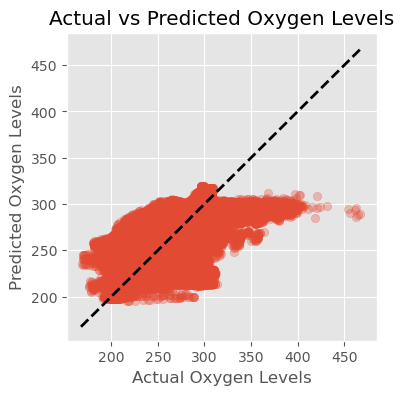

In [26]:
# Import necessary libraries for regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


df_linear = df2.copy()

# Define features and target for regression
# We'll predict oxygen levels (continuous variable)
features = ['sea_water_temperature', 'sea_water_practical_salinity',
            'sea_water_density', 'depth']
target = 'micromoles_of_oxygen_per_unit_mass_in_sea_water'
# Drop NaN values
df_linear = df_linear.dropna(subset=features + [target])

# Normalization of numerical variables
scaler = StandardScaler()
num_features = ['sea_water_temperature', 'sea_water_practical_salinity',
                'sea_water_density', 'depth']
df_linear[num_features] = scaler.fit_transform(df_linear[num_features])

# One-hot encoding categorical variables
# Include 'Depth_level' in the categorical features
categorical_features = ['Season', 'DayNight', 'Month_n', 'Depth_level']
df3 = pd.get_dummies(df_linear, columns=categorical_features, drop_first=True)

# Instead of excluding columns, explicitly select the ones you want
features = num_features + [col for col in df3.columns if col.startswith(('Season_', 'DayNight_', 'Month_n_', 'Depth_level_'))]


X = df3[features]
y = df3[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Make predictions
y_pred = linear_reg.predict(X_test) # Call predict with X_test

# Evaluate the model
print("Linear Regression Results:")
# How well the model fits the data , Higher is better
print(f"R-squared (R²): {r2_score(y_test, y_pred):.2f}") # R^2 , variance of the dependent variable(target) explained by independent variables
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}") # absolute square distance between the predicted and target values
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}") # mean square distance between the predicted and actual values
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}") # Calculate RMSE using np.sqrt


#  Print coefficients
print("\nFeature Coefficients:")
for feature, coef in zip(features, linear_reg.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {linear_reg.intercept_:.4f}")

#  Plot actual vs predicted values
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual Oxygen Levels')
plt.ylabel('Predicted Oxygen Levels')
plt.title('Actual vs Predicted Oxygen Levels')
plt.show()

Above we have plotted a scatterplot comparing the actual and predicted oxygen levels from this model. If this model were to accurately predict data, the points would follow the black line. However, we see that the points are scattered around. This may suggest that this model does not predict accurately, and we should test other models with different features.

In [27]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 6. Add constant for intercept and verify no NaN/inf
X = sm.add_constant(X)

# Convert all columns of X to numeric, coercing errors to NaN
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')  # Convert to numeric

# Check and handle NaN/inf values column-wise
for col in X.columns:
    # Check for NaN values and replace with 0
    X[col] = X[col].fillna(0)

    # Check for infinite values and replace with a large finite value
    X[col] = X[col].replace([np.inf, -np.inf], np.finfo(np.float64).max)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train.astype(float))  # Ensure X_train is of type float
ols_results = ols_model.fit()
# Print comprehensive summary
print(ols_results.summary())

# --- Additional Evaluation (matching your sklearn metrics) ---
y_pred = ols_results.predict(X_test)

print("\nValidation Metrics:")
print(f"R-squared (R²): {ols_results.rsquared:.2f}")
print(f"Adjusted R²: {ols_results.rsquared_adj:.2f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")



                                           OLS Regression Results                                          
Dep. Variable:     micromoles_of_oxygen_per_unit_mass_in_sea_water   R-squared:                       0.662
Model:                                                         OLS   Adj. R-squared:                  0.662
Method:                                              Least Squares   F-statistic:                 5.450e+05
Date:                                             Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                                                     23:31:16   Log-Likelihood:            -1.5307e+07
No. Observations:                                          3612364   AIC:                         3.061e+07
Df Residuals:                                              3612350   BIC:                         3.061e+07
Df Model:                                                       13                                         
Covariance Type:            

Results of this model:

R-squared (R²): 0.66
Adjusted R²: 0.66
Mean Absolute Error (MAE): 12.39
Root Mean Squared Error (RMSE): 16.75

While some months have high p values, others don't, this implies that month is a statistically significant feature. In addition, features such as salinity, and depth also have low p-values which indicate their statistical significance.

Residual Analysis on the training - testing Model

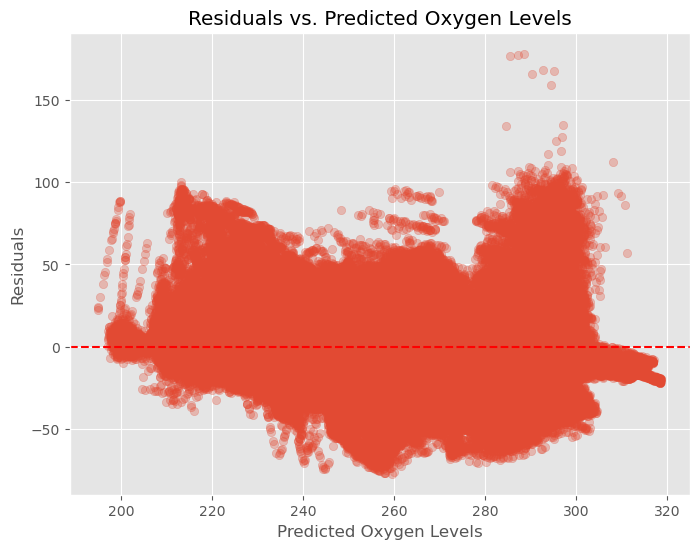

In [28]:
#Plot the residuals
# The residuals are plotted against the predicted values of the target variable.
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test - y_pred, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Oxygen Levels')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Oxygen Levels')
plt.show()

The residuals appear scattered which suggests homoscedasticity.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
# Plot the histogram of the original values
sns.histplot(y_test, bins=20, kde=True, color='blue', label='Original')
sns.histplot(y_pred, bins=20, kde=True, color='red', label='Predicted')
plt.xlabel('Oxygen Levels')
plt.ylabel('Frequency')
plt.title('Histogram of Original and Predicted Oxygen Levels')
plt.legend()

Above we have plotted the histogram of the target variable. It appears non-gaussian. This suggests we must apply some transformation to normalize the distribution.

C:\Users\zelko\AppData\Local\Temp\ipykernel_49032\631556793.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_log.dropna(), fit=stats.norm, kde=False) # dropna() to exclude the infinite values, preventing the OverflowError


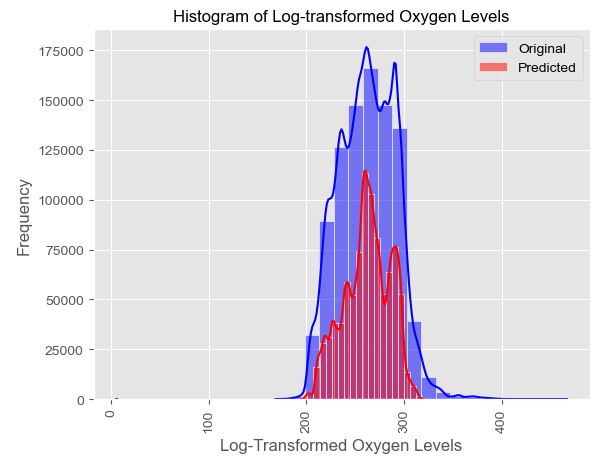

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
y_log = np.log(df3[target] + 1e-6)
# Replace infinite values with a finite large value
y_log = y_log.replace([np.inf, -np.inf], np.nan)  # Use np.nan to represent infinite values

# Plot the histogram using y_log
sns.distplot(y_log.dropna(), fit=stats.norm, kde=False) # dropna() to exclude the infinite values, preventing the OverflowError
sns.set(color_codes=True)
plt.xticks(rotation=90)
plt.title("Histogram of Log-transformed Oxygen Levels")
plt.xlabel("Log-Transformed Oxygen Levels")
plt.ylabel("Frequency")
plt.show()

After applying a log transformations on the target variable (oxygen concentration), the target variable follows a normal distribution

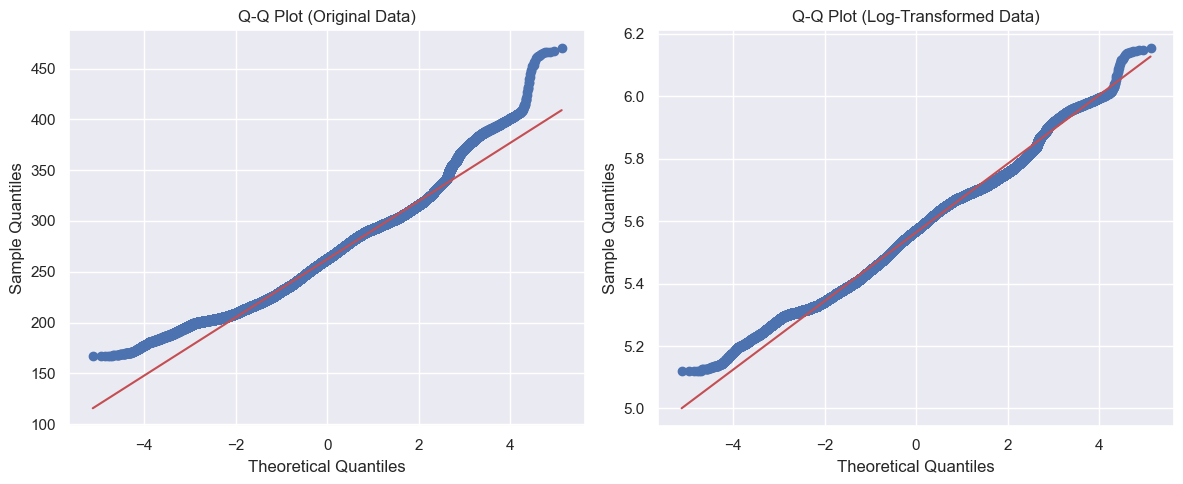

In [31]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Assuming 'df3' is your DataFrame and 'target' is the column of interest
y_original = df3[target].dropna()  # Original data (drop NaN if any)
y_log = np.log(df3[target] + 1e-6).replace([-np.inf, np.inf], np.nan).dropna()  # Log-transformed (handling 0 and inf)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for original data
stats.probplot(y_original, dist="norm", plot=ax1)
ax1.set_title("Q-Q Plot (Original Data)")
ax1.set_xlabel("Theoretical Quantiles")
ax1.set_ylabel("Sample Quantiles")

# Q-Q plot for log-transformed data
stats.probplot(y_log, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot (Log-Transformed Data)")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

After the log transformation (right qq plot), the target variables follows a more normal distribution.

Linear Regression on Various Model and it's Results

In [32]:
import statsmodels.formula.api as smf
import numpy as np
import statsmodels.formula.api as smf
import numpy as np

# Ensure 'Month_n' is a column in df3 (If not, create it):
if 'Month_n' not in df3.columns or 'Season_n' not in df3.columns:
    df3['Month_n'] = df3['time'].dt.month.astype('category') # Recreating 'Month_n' if it's missing
    df3['Season_n'] = df3['time'].dt.month.astype('category')

# Define formula (Modify as needed):
formula9 = 'np.log(micromoles_of_oxygen_per_unit_mass_in_sea_water) ~   C(Month_n) + depth + np.log(sea_water_temperature) + sea_water_practical_salinity + sea_water_density'

# Fit the model:
model9 = smf.ols(formula=formula9, data=df3)  #Using 'formula=' for clarity
results = model9.fit()

print(results.summary())



C:\Users\zelko\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\zelko\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                                               OLS Regression Results                                              
Dep. Variable:     np.log(micromoles_of_oxygen_per_unit_mass_in_sea_water)   R-squared:                       0.749
Model:                                                                 OLS   Adj. R-squared:                  0.749
Method:                                                      Least Squares   F-statistic:                 7.039e+05
Date:                                                     Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                                                             23:32:42   Log-Likelihood:             2.6355e+06
No. Observations:                                                  1652057   AIC:                        -5.271e+06
Df Residuals:                                                      1652049   BIC:                        -5.271e+06
Df Model:                                                               

Model 9 Results :

We found the R^2 = 0.748 and p values < 0.005 which shows that all features included are statistically significant.

This model also has a very small AIC value.

In [33]:
formula0 = 'micromoles_of_oxygen_per_unit_mass_in_sea_water~ latitude + longitude + depth + sea_water_temperature + np.log(sea_water_practical_salinity)+sea_water_density'

# 3. Fit the model
model0 = smf.ols(formula0, data=df3)
results = model0.fit()
print(results.summary())

C:\Users\zelko\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\zelko\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                                           OLS Regression Results                                          
Dep. Variable:     micromoles_of_oxygen_per_unit_mass_in_sea_water   R-squared:                       0.408
Model:                                                         OLS   Adj. R-squared:                  0.408
Method:                                              Least Squares   F-statistic:                 3.155e+05
Date:                                             Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                                                     23:32:47   Log-Likelihood:            -1.2206e+07
No. Observations:                                          2751273   AIC:                         2.441e+07
Df Residuals:                                              2751266   BIC:                         2.441e+07
Df Model:                                                        6                                         
Covariance Type:            

Model 0 Results:

All p-values are less than 0.05, this indicates all features included are statistically significant.

The r-squared value is 0.561, this shows the last model - model 9 (has higher r-squared value), explains the variability better.

In [34]:
formula1 = 'np.log(micromoles_of_oxygen_per_unit_mass_in_sea_water)~ latitude + longitude + depth + sea_water_temperature + sea_water_practical_salinity+sea_water_density'
model1 = smf.ols(formula1, data=df3)
results = model1.fit()
print(results.summary())

                                               OLS Regression Results                                              
Dep. Variable:     np.log(micromoles_of_oxygen_per_unit_mass_in_sea_water)   R-squared:                       0.579
Model:                                                                 OLS   Adj. R-squared:                  0.579
Method:                                                      Least Squares   F-statistic:                 1.036e+06
Date:                                                     Fri, 04 Apr 2025   Prob (F-statistic):               0.00
Time:                                                             23:32:53   Log-Likelihood:             5.4917e+06
No. Observations:                                                  4515455   AIC:                        -1.098e+07
Df Residuals:                                                      4515448   BIC:                        -1.098e+07
Df Model:                                                               

Model 1 Results:

All p-values are less than 0.05, this indicates all features included are statistically significant.

The r-squared value is 0.579, this shows the last model - model 9 (has higher r-squared value), explains the variability better.

Residual Analysis on Model 9

In [35]:
# Fit the model and get the results
results = model9.fit()

# Filter df3 to match the index of the model's data
filtered_df3 = df3.loc[results.resid.index]

# Now plot using the filtered DataFrame
plt.semilogx(filtered_df3["micromoles_of_oxygen_per_unit_mass_in_sea_water"], results.resid, ".", alpha=0.2)
plt.ylabel("Residuals")
plt.xlabel("Oxygen Levels")
plt.title("Residuals vs. Oxygen Levels")
plt.axhline(0, color="black")

From the plot above, the residuals are not randomly scattered which may indicate some heteroscedasticity.

In [36]:
import scipy
# Fit the model to get the results
results = model9.fit()

plt.hist(results.resid, # Access residuals from the results object
    density=True,     # the histogram integrates to 1
                      # (so it can be compared to the normal distribution)
    bins=100,         #  draw a histogram with 100 bins of equal width
    label="residuals" # label for legend
    )
# now plot the normal distribution for comparison
xx = np.linspace(results.resid.min(), results.resid.max(), num=1000) # Use results.resid here as well
plt.plot(xx, scipy.stats.norm.pdf(xx, loc=0.0, scale=np.sqrt(results.scale)), # Use results.scale
    label="normal distribution")
outliers = np.abs(results.resid)>4*np.sqrt(results.scale) # Use results.resid and results.scale
sns.rugplot(results.resid[outliers], # Use results.resid
            color="C5", # otherwise the rugplot has the same color as the histogram
            label="outliers")
plt.legend(loc="upper right");

The residuals follow a normal distribution with some outliers. These outliers appear even on either side of the distribution.

In [37]:
# Fit the model to get the results
results = model9.fit()

# Now you can access the residuals using results.resid
sm.qqplot(results.resid, line="s", markeredgecolor='b', markerfacecolor='b');

The QQ plot of the residuals appears mostly normal except for a heavy right tail.

Root mean square error

In [38]:
import numpy as np

#Get the predicted values using the model
predictions = results.fittedvalues

#Get the actual values using the log transformation
actuals = np.log(df3['micromoles_of_oxygen_per_unit_mass_in_sea_water'])

#Calculate residuals
residuals = actuals - predictions

#Compute RMSE
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE: {rmse}")

RMSE: 0.04908321549834362
